# AutoML for Classification Model Screening

The following are the steps for using AutoML for a regression task:

_Note: Setting the flag for featurization= 'True' generates represents molecules using 5 representation techniques._ 

1. Requires an input pandas dataframe consisting of two columns:<br>
    * SMILES strings<br>
    * target class values<br>


2. If featurization = True, Molecules are represented as:<br>
    * Coulomb matrix<br>
    * RDKit Morgan (ECFP6 1024-bit) fingerprints<br>
    * MACCs keys<br>
    * RDKit hashed topological torsion<br>
    * RDKit molecular descriptors (all)<br>
    * Mordred molecular descriptors (currently using base Mordred)<br>


3. Screens through various classifier models:<br>
    * Single-core (runs regardless of multi_core value):
        * [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)<br>
        * [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)<br>
        * [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)<br>
        * [KNeighboursClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)<br>
    * Multi-core(set multi_core=True):
        * [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)<br>
        * [ChemML_MLP](https://hachmannlab.github.io/chemml/ipython_notebooks/ml_model.html) (if n_datapoints>500)<br>
        * (optional) [XGBClassifier](https://xgboost.readthedocs.io/en/latest/python/python_api.html)<br>
        * (optional) [LightGBM](https://lightgbm.readthedocs.io/en/stable/)

Yields 'n-best' models, with optimized hyperparamters.

The output_dir argument specifies a folder that will be created wherever the code is run from, containing the following directory tree:

<pre> &lt;output_dir&gt;/<br> |-- output.log<br> |-- scores.csv<br> |-- best_model/<br> |   |-- model.pkl # most non-MLP models<br> |   |-- model_chemml_model.json # MLP case (plus possible extra model files)<br> |   |-- scaler.pkl # present when scaler exists for chosen feature_key<br> |   |-- feature_order.json<br> |   |-- metadata.json<br> |-- .model_screener_artifacts/<br> |   |-- &lt;run_key_1&gt;/<br> |        |-- model.pkl # or MLP artifact files<br> |   |-- &lt;run_key_2&gt;/<br>... </pre>

## Load your data 

We are using ChemML's in-built dataset to demonstrate the minimum requirements to run AutoML.

In [1]:
import pandas as pd
from chemml.datasets import load_organic_density

In [2]:
molecules, target, dragon_subset = load_organic_density()
df=pd.concat([molecules, target], axis=1)
df = df.sample(200, random_state=42)
df

,smiles,density_Kg/m3
361,c1scc(n1)c1ncc(s1)c1c(ccc2c1cccc2)c1cncs1,1328.35
73,S1CC(SC(C1)C1CCCC1)c1cocc1c1ccccc1,1143.80
374,N1CNC(NC1)c1sccc1C1(CSCCS1)c1cccs1,1351.33
155,c1nc(c(s1)c1nsnc1)c1csc(n1)c1cccs1,1466.57
104,Oc1ccc2c(c1c1cocc1)c(ccc2)c1ccccn1,1207.67
...,...,...
248,Oc1ncc(c(c1)C)c1cnccn1,1195.16
145,Sc1cc2ccccc2c(c1)c1cnccc1c1cnccn1,1213.41
92,c1sc(c(c1)c1ncccc1c1nsnc1)c1ccc2c(c1)cccc2,1264.16
152,N1CNC(NC1)(N1CNC(NC1)c1cncs1)c1cccc2c1cccc2,1270.40


In [3]:
# Labeling data for classification instead of regression
# Note: This is just for demonstration purposes. In practice, you would want to use a regression model for predicting density.
df['density_class'] = pd.qcut(df['density_Kg/m3'], q=3, labels=range(3))

## Run autoML for a classification task

In [ ]:
from chemml.autoML import ModelScreener
MS = ModelScreener(df, target="density_class", featurization=True, cache_features=False, cache_models=False, smiles="smiles", 
                   screener_type="classifier", output_dir="automl_results_class")
scores = MS.screen_models(n_best=10, multi_core=True)



-------------------------ChemML AutoML Model Screening-------------------------

-------------------------Model screening started at Wed Aug 19 14:22:08 2026-------------------------



Converting SMILES to ChemML Molecule objects...



Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:07<00:00, 28.04it/s]



Generating Coulomb matrix representation...

featurizing molecules in batches of 12 ...
200/200 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step  
Merging batch features ...    [DONE]

Generating RDKit fingerprint representations...



Generating MACCS Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 880.23molecule/s]
Generating Hashed Topological Torsion Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 7916.40molecule/s]
Generating Atom Pair Fingerprints: 100%|██████████| 200/200 [00:00<00:00, 7364.57molecule/s]



Generating RDKit descriptor representations...

Step 1: Normalizing molecule input


Step 2: Calculating RDKit descriptors: 100%|██████████| 200/200 [00:02<00:00, 92.02it/s]



Generating Mordred descriptor representations...

Step 1: Normalizing molecule input


Normalizing Molecule input: 100%|██████████| 200/200 [00:00<00:00, 28016.19it/s]


Step 2/3: Optimizing geometry for 3D descriptor calculation


3D geometry already exists, loading geometry: 100%|██████████| 200/200 [00:00<?, ?it/s]

Step 3/3: Calculating Mordred descriptors



100%|██████████| 200/200 [00:06<00:00, 31.10it/s]



Cleaning feature sets to remove constant, highly correlated, and low-variance features...

Feature set 'CoulombMatrix' cleaned: 25 features retained.

Feature set 'morganfingerprints_radius3' cleaned: 252 features retained.

Feature set 'MACCS_radius3' cleaned: 48 features retained.

Feature set 'hashedtopologicaltorsion_radius3' cleaned: 76 features retained.

Feature set 'hashedatompair_radius3' cleaned: 421 features retained.

Feature set 'rdkit_descriptors' cleaned: 90 features retained.

Feature set 'mord_descriptors' cleaned: 530 features retained.


-------------------------Run parameters-------------------------
  Featurization: True
  Multi_core: True
  Screener_type: classifier
  Number of datapoints: 200
MLP thread limit: 1 (hard-coded)
  Multi-core models: RandomForestClassifier, MLPClassifier, XGBClassifier, LGBMClassifier
  Note: Dataset <= 500 samples; MLP is excluded from screening due to inefficiency.

split done!
Single-core complete 


Running model no: 1; Name: Ran

Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.009632386631435818

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.0009696143865585327

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.007203352914916144

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.0032538329230414496

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set CoulombMatrix, time taken: 91.085 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.01039053393734826

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.001238671408759223

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.008644178443484836

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.0032669031620025635

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set morganfingerprints_radius3, time taken: 98.451 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.009414092169867622

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.0010510785049862332

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.0061060651143391926

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.003311191466119554

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set MACCS_radius3, time taken: 85.715 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.009222084151373969

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.0009262665112813314

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.006653803388277689

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.0030397552251815794

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set hashedtopologicaltorsion_radius3, time taken: 85.057 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.009404874179098341

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.0014661580986446805

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.012589094042778016

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.005827334854337904

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set hashedatompair_radius3, time taken: 119.697 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.00998564342657725

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.001255671117040846

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.012655532889895968

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.00428205046388838

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set rdkit_descriptors, time taken: 117.585 seconds -------------------------

split done!
Single-core complete 


Running model no: 1; Name: RandomForestClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

RandomForestClassifier: GeneticAlgorithm - complete
Model: RandomForestClassifier
GA time(hours): 0.010804018643167284

--------------------------------------------------------------------------------

Running model no: 2; Name: MLPClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

MLPClassifier: GeneticAlgorithm - complete
Model: MLPClassifier
GA time(hours): 0.0017826458480623033

--------------------------------------------------------------------------------

Running model no: 3; Name: XGBClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

XGBClassifier: GeneticAlgorithm - complete
Model: XGBClassifier
GA time(hours): 0.03367804997497135

--------------------------------------------------------------------------------

Running model no: 4; Name: LGBMClassifier


Generation:   0%|          | 0/10 [00:00<?, ?gen/s]

LGBMClassifier: GeneticAlgorithm - complete
Model: LGBMClassifier
GA time(hours): 0.006816907525062561

--------------------------------------------------------------------------------

------------------------- Screening complete for feature set mord_descriptors, time taken: 209.107 seconds -------------------------



In [5]:
scores

,Model,Accuracy,Recall,Precision,F1-score,time(seconds),parameters,Feature,run_key
47,XGBClassifier,1.0,1.0,1.0,1.0,121.872709,"[{'objective': 'multi:softprob', 'base_score':...",mord_descriptors,XGBClassifier_mord_descriptors_fbbf57ad27e64dd...
45,RandomForestClassifier,0.95,0.944444,0.958333,0.947475,39.000457,"[{'bootstrap': True, 'ccp_alpha': 0.0, 'class_...",mord_descriptors,RandomForestClassifier_mord_descriptors_9dc709...
48,LGBMClassifier,0.9,0.904762,0.904762,0.901099,24.802016,"[{'boosting_type': 'gbdt', 'class_weight': Non...",mord_descriptors,LGBMClassifier_mord_descriptors_0dc6ba263da54e...
43,DecisionTreeClassifier,0.85,0.84127,0.85,0.842424,4.992352,"[{'ccp_alpha': 0.0, 'class_weight': None, 'cri...",mord_descriptors,DecisionTreeClassifier_mord_descriptors_6c6dc1...
44,KNeighborsClassifier,0.8,0.801587,0.833333,0.809441,7.659064,"[{'algorithm': 'auto', 'leaf_size': 30, 'metri...",mord_descriptors,KNeighborsClassifier_mord_descriptors_f6a1af7a...
37,KNeighborsClassifier,0.75,0.753968,0.763889,0.75641,7.56913,"[{'algorithm': 'auto', 'leaf_size': 30, 'metri...",rdkit_descriptors,KNeighborsClassifier_rdkit_descriptors_3384aee...
46,MLPClassifier,0.7,0.706349,0.777778,0.662037,6.462787,"[{'activation': 'identity', 'alpha': 0.0002069...",mord_descriptors,MLPClassifier_mord_descriptors_c7848e54eda148f...
39,MLPClassifier,0.65,0.650794,0.640476,0.638462,4.560445,"[{'activation': 'identity', 'alpha': 0.0006158...",rdkit_descriptors,MLPClassifier_rdkit_descriptors_6558c991e14c44...
31,RandomForestClassifier,0.6,0.595238,0.604762,0.597691,34.107416,"[{'bootstrap': True, 'ccp_alpha': 0.0, 'class_...",hashedatompair_radius3,RandomForestClassifier_hashedatompair_radius3_...
34,LGBMClassifier,0.55,0.539683,0.59596,0.538462,21.065225,"[{'boosting_type': 'gbdt', 'class_weight': Non...",hashedatompair_radius3,LGBMClassifier_hashedatompair_radius3_a948cd85...


## Validating AutoML-generated model

Since ChemML v1.3.4, AutoML outputs the best model and required scaler and feature order as easy-to-import files. A quick demonstration of the model loading workflow is given below:

In [6]:
import pickle
import json

with open('automl_results_class/best_model/metadata.json', 'r') as f:
    metadata = json.load(f)
with open('automl_results_class/best_model/feature_order.json', 'r') as f:
    feature_order = json.load(f)
with open("automl_results_class/best_model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("automl_results_class/best_model/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

Metadata isn't necessary for model validation, but gives us a lot of context from the AutoML screening workflow.

In [7]:
metadata

{'artifact_schema_version': 1,
 'model_name': 'XGBClassifier',
 'feature_key': 'mord_descriptors',
 'run_key': 'XGBClassifier_mord_descriptors_fbbf57ad27e64dd1a5b6c10512467f7b',
 'screener_type': 'classifier',
 'parameters': {'objective': 'multi:softprob',
  'base_score': None,
  'booster': None,
  'callbacks': None,
  'colsample_bylevel': None,
  'colsample_bynode': None,
  'colsample_bytree': 0.6417419982753503,
  'device': 'cpu',
  'early_stopping_rounds': None,
  'enable_categorical': False,
  'eval_metric': None,
  'feature_types': None,
  'feature_weights': None,
  'gamma': 0.012157969509318967,
  'grow_policy': None,
  'importance_type': None,
  'interaction_constraints': None,
  'learning_rate': 0.08568773973458872,
  'max_bin': None,
  'max_cat_threshold': None,
  'max_cat_to_onehot': None,
  'max_delta_step': None,
  'max_depth': 6,
  'max_leaves': None,
  'min_child_weight': 4,
  'missing': nan,
  'monotone_constraints': None,
  'multi_strategy': None,
  'n_estimators': 140,

feature_order ensures that the trained model sees features in the exact same order as trained.

In [8]:
feature_order[:5]

['ABC', 'ABCGG', 'nBase', 'SpDiam_A', 'nAromAtom']

In [9]:
from chemml.chem import Molecule
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tqdm
from chemml.chem import Mordred
from sklearn.svm import SVR

mol_objs_list = []
for i, smi in enumerate(tqdm.tqdm(df["smiles"], desc="Converting SMILES to ChemML Molecule objects")):
    mol = Molecule(smi, 'smiles')
    mol.hydrogens('add')
    try:
        mol.to_xyz('MMFF', maxIters=10000, mmffVariant='MMFF94s')
        mol_objs_list.append(mol)
    except Exception as e:
        print(f"\nUnable to process SMILES: {smi}; Error: {e}")
        # self.discarded_indices.append(i)
loaded_mols = mol_objs_list
features = Mordred(ignore_3D=False).represent(loaded_mols).drop(columns=['SMILES'])[feature_order].values
targets = df["density_class"].values


X_test = loaded_scaler.transform(features)

y_pred = loaded_model.predict(X_test)
y_pred_proba = loaded_model.predict_proba(X_test)

Converting SMILES to ChemML Molecule objects: 100%|██████████| 200/200 [00:06<00:00, 28.96it/s]


Step 1: Normalizing molecule input
Step 2/3: Optimizing geometry for 3D descriptor calculation
Step 3/3: Calculating Mordred descriptors


The loaded_model object can be treated just like any model object

In [10]:
loaded_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.6417419982753503)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python fro

In [11]:
targets[:5], y_pred[:5]

([2, 0, 2, 2, 0]
 Categories (3, int64): [0 < 1 < 2],
 array([2, 0, 2, 2, 0]))

In [12]:
from chemml.utils import classification_metrics
classification_metrics(targets, y_pred)

TP:  [67 66 67]
FP:  [0 0 0]
TN:  [133 134 133]
FN : [0 0 0]
Accuracy:  1.0
Precision:  [1. 1. 1.]
Recall:  [1. 1. 1.]
f1_score:  [1. 1. 1.]
FPR:  [0. 0. 0.]
TPR:  [1. 1. 1.]
               0      1      2
TP          67.0   66.0   67.0
TN         133.0  134.0  133.0
FP           0.0    0.0    0.0
FN           0.0    0.0    0.0
precision    1.0    1.0    1.0
recall       1.0    1.0    1.0
f1_score     1.0    1.0    1.0
TPR          1.0    1.0    1.0
FPR          0.0    0.0    0.0
TNR          1.0    1.0    1.0
PPV          1.0    1.0    1.0
NPV          1.0    1.0    1.0
FNR          0.0    0.0    0.0
FDR          0.0    0.0    0.0


(np.float64(1.0),
       0     1     2
 0  67.0   0.0   0.0
 1   0.0  66.0   0.0
 2   0.0   0.0  67.0,
                0      1      2
 TP          67.0   66.0   67.0
 TN         133.0  134.0  133.0
 FP           0.0    0.0    0.0
 FN           0.0    0.0    0.0
 precision    1.0    1.0    1.0
 recall       1.0    1.0    1.0
 f1_score     1.0    1.0    1.0
 TPR          1.0    1.0    1.0
 FPR          0.0    0.0    0.0
 TNR          1.0    1.0    1.0
 PPV          1.0    1.0    1.0
 NPV          1.0    1.0    1.0
 FNR          0.0    0.0    0.0
 FDR          0.0    0.0    0.0)

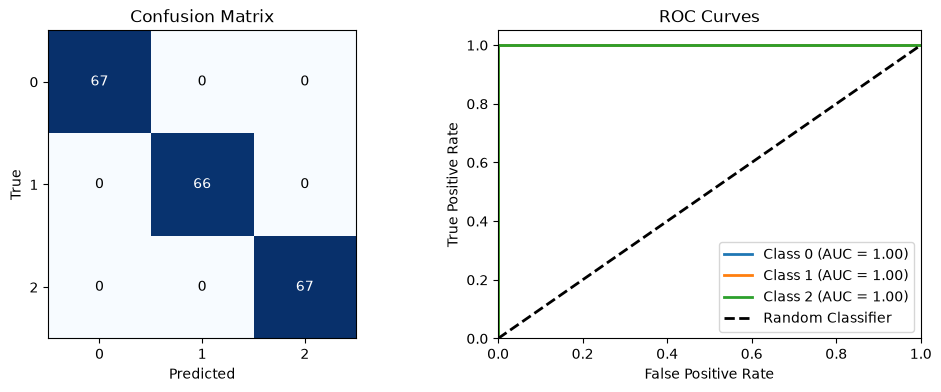

In [13]:
%matplotlib inline
from chemml.visualization import ClassificationPlots


plotter = ClassificationPlots().plot(targets, y_pred, y_pred_proba)
display(plotter)